In [1]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import matplotlib.pyplot as plt
import cv2

import torch
from detectron2.structures import Boxes, Instances

In [2]:
from torchvision.ops import roi_align
import torchvision.transforms.functional as F

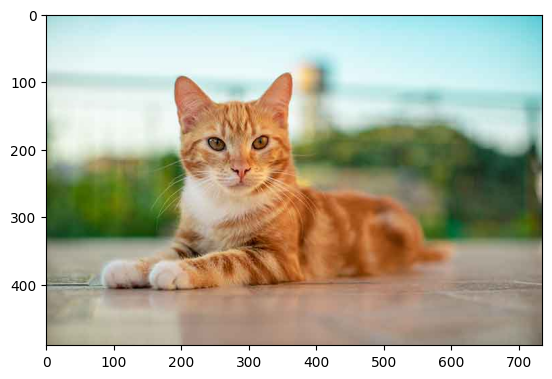

In [3]:
img = cv2.imread("cat-facts.jpg")
img_copy = img[:,:,::-1].copy()
plt.imshow(img_copy)

In [4]:
v = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("coco_2017_train"), scale=1.2)

In [5]:
boxes = [[184, 90, 370, 260]]

In [6]:
instances = Instances(img.shape[:2])  # height, width
instances.pred_boxes = Boxes(torch.tensor(boxes))

In [7]:
instances.scores = torch.tensor([0.9])   # optional
instances.pred_classes = torch.tensor([17])  # class id (예: 17=cat in COCO)

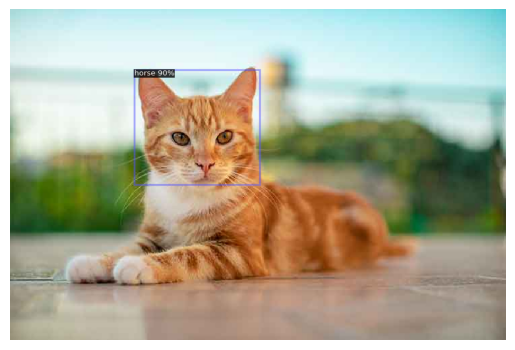

In [8]:
out = v.draw_instance_predictions(instances)
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

In [13]:
# 2) 텐서로 변환 → (C,H,W) in [0,1]
img_in = img[:,:,::-1]
x = F.to_tensor(img_copy)           
x = x.unsqueeze(0)              
print(f"x.shape:{x.shape}")

x.shape:torch.Size([1, 3, 490, 735])


In [20]:
# 3) RoIs: (batch_idx, x1, y1, x2, y2)  --- 위에서 표시한 두 박스 그대로 사용
rois = torch.tensor([
    [[0, 184, 90, 370, 260],],
], dtype=torch.float)

In [25]:
rois = rois.squeeze(0)

In [24]:
rois.shape

torch.Size([1, 1, 5])

In [28]:
# 4) ROIAlign 레이어 설정
#   - 이번 예시는 '이미지 자체를 feature map'처럼 사용하므로 downscale이 없어서 spatial_scale=1.0
#   - 보통은 backbone stride(예: 16)에 따라 spatial_scale=1/16 등으로 설정
roi_align_layer = lambda feat, boxes: roi_align(
    feat, boxes,
    output_size=(80, 80),    # 원하는 출력 크기
    spatial_scale=1.0,     # 이번 예시: 이미지 좌표 == feature 좌표
    sampling_ratio=0,
    aligned=True
)

# 5) 실행
pooled = roi_align_layer(x, rois)   # shape: (B=2, C=3, 7, 7)
print("pooled.shape:", pooled.shape)

pooled.shape: torch.Size([1, 3, 80, 80])


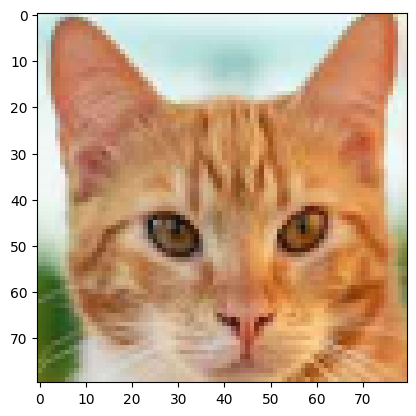

In [29]:
roi0 = pooled[0]
roi0_img = roi0.permute(1, 2, 0).detach().cpu().numpy()
plt.imshow(roi0_img)

In [31]:
135/16

8.4375